# Demand Forecasting Pipeline — All Categories

This notebook implements a reusable pipeline that runs the full 
forecasting workflow for any given category.

- Reference: `split_comparison.ipynb` for split strategy justification.
- Reference: `02_single_category_analysis_and_models.ipynb` for 
detailed analysis on 5 representative categories.

### Imports:

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer
from sklearn.feature_selection import mutual_info_regression
from sklearn.base import clone
from xgboost import XGBRegressor

daily = pd.read_csv(r"C:\Users\user\internship\daily_category_sales_clean.csv")
daily["Date"] = pd.to_datetime(daily["Date"])
daily = daily[daily["Category"] != "Miscellaneous"]

all_categories = daily["Category"].unique().tolist()
print(f"Dataset loaded: {daily.shape}")
print(f"Categories: {len(all_categories)}")

Dataset loaded: (20196, 5)
Categories: 54


### Holiday dates:

In [35]:
holiday_dates = set(
    pd.to_datetime([
        "2010-12-25", "2010-12-26", "2010-12-27", "2010-12-28",
        "2011-01-01", "2011-01-03",
        "2011-04-22", "2011-04-25",
        "2011-05-02", "2011-05-30",
        "2011-08-29",
        "2011-12-25", "2011-12-26", "2011-12-27"
    ]).date
)
print(f"Holiday dates defined: {len(holiday_dates)}")

Holiday dates defined: 14


In [39]:
def preprocess(daily_data, category_name, X=7, Y=7, holiday_dates=None):
    """
    Prepare forecasting dataset for one category.
    Creates target variable, lag features, rolling features,
    calendar features, and holiday features.
    """
    df = (daily_data[daily_data["Category"] == category_name]
          .sort_values("Date")
          .copy()
          .reset_index(drop=True))

    df = df[["Date", "Category", "Quantity"]].copy()

    # Target
    quantities = df["Quantity"].to_numpy()
    targets = []
    for i in range(len(df)):
        start = i + Y
        end   = start + X
        targets.append(quantities[start:end].sum() if end <= len(df) else np.nan)
    df[f"target_X{X}_Y{Y}"] = targets

    # Lag features
    for lag in list(range(1, 8)) + [14, 28]:
        df[f"lag_{lag}"] = df["Quantity"].shift(lag)

    # Rolling features (shifted by 1 to avoid leakage)
    shifted = df["Quantity"].shift(1)
    for window in [7, 14, 28]:
        df[f"rolling_mean_{window}"] = shifted.rolling(window).mean()
        df[f"rolling_std_{window}"]  = shifted.rolling(window).std()
        df[f"rolling_min_{window}"]  = shifted.rolling(window).min()
        df[f"rolling_max_{window}"]  = shifted.rolling(window).max()
        df[f"rolling_sum_{window}"]  = shifted.rolling(window).sum()

    # Weekly means
    df["weekly_mean_2"] = shifted.rolling(14).mean()
    df["weekly_mean_3"] = shifted.rolling(21).mean()
    df["weekly_mean_4"] = shifted.rolling(28).mean()

    # Trend
    df["trend_7_28"] = df["rolling_mean_7"] - df["rolling_mean_28"]

    # Calendar features
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"]       = df["Date"].dt.month

    # Holiday features
    if holiday_dates:
        df["is_holiday"] = df["Date"].dt.date.isin(holiday_dates).astype(int)
        df["number_of_holidays_in_target_window"] = df["Date"].apply(
            lambda d: sum(
                1 for i in range(Y, Y + X)
                if (d + pd.Timedelta(days=i)).date() in holiday_dates
            )
        )
        df["holiday_in_target_window"] = (
            df["number_of_holidays_in_target_window"] > 0
        ).astype(int)
    else:
        df["is_holiday"] = 0
        df["number_of_holidays_in_target_window"] = 0
        df["holiday_in_target_window"] = 0

    return df.dropna().reset_index(drop=True)


In [43]:
def split_data(data, block_size=14, train_size=0.70,
               val_size=0.15, random_state=42):
    """
    Block-shuffled train/validation/test split.
    """
    data = data.sort_values("Date").reset_index(drop=True)
    n_blocks = int(np.ceil(len(data) / block_size))
    block_ids = np.repeat(np.arange(n_blocks), block_size)[:len(data)]
    data = data.copy()
    data["block_id"] = block_ids
    unique_blocks = data["block_id"].unique()
    rng = np.random.default_rng(random_state)
    rng.shuffle(unique_blocks)
    n_train = int(len(unique_blocks) * train_size)
    n_val   = int(len(unique_blocks) * val_size)
    train_blocks = unique_blocks[:n_train]
    val_blocks   = unique_blocks[n_train:n_train + n_val]
    test_blocks  = unique_blocks[n_train + n_val:]
    train = data[data["block_id"].isin(train_blocks)].drop(columns="block_id").reset_index(drop=True)
    val   = data[data["block_id"].isin(val_blocks)].drop(columns="block_id").reset_index(drop=True)
    test  = data[data["block_id"].isin(test_blocks)].drop(columns="block_id").reset_index(drop=True)
    return train, val, test

In [45]:
def evaluate_forecast(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.maximum(y_pred, 0)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.sum(np.abs(y_true))
    wape = (np.sum(np.abs(y_true - y_pred)) / denom) * 100 if denom > 0 else np.nan
    r2   = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    return mae, rmse, wape, r2, bias


In [47]:
def select_features(train_df, features, target_col, n_features=10):
    """
    Rank features by mutual information and return top n.
    """
    mi_scores = mutual_info_regression(
        train_df[features], train_df[target_col], random_state=42
    )
    ranked = [features[i] for i in np.argsort(mi_scores)[::-1]]
    return ranked[:n_features]

In [51]:
def train_and_evaluate(splits, features, target_col):
    """
    Train all models on block-shuffled splits.
    Returns results dataframe with validation WAPE per model.
    """
    train_df = splits["train"]
    val_df   = splits["validation"]
    test_df  = splits["test"]

    y_train = train_df[target_col]
    y_val   = val_df[target_col]
    y_test  = test_df[target_col]

    models = {
        "Baseline":          None,
        "Linear Regression": LinearRegression(),
        "Random Forest":     RandomForestRegressor(
                                 n_estimators=200, random_state=42, n_jobs=-1),
        "XGBoost":           XGBRegressor(
                                 n_estimators=200, learning_rate=0.05,
                                 max_depth=6, random_state=42, verbosity=0)
    }

    results = []
    predictions = {}

    for model_name, model in models.items():
        if model_name == "Baseline":
            train_pred = train_df["rolling_sum_7"].values
            val_pred   = val_df["rolling_sum_7"].values
            test_pred  = test_df["rolling_sum_7"].values
        else:
            # Feature selection
            selected = select_features(train_df, features, target_col)
            model.fit(train_df[selected], y_train)
            train_pred = model.predict(train_df[selected])
            val_pred   = model.predict(val_df[selected])
            test_pred  = model.predict(test_df[selected])

        _, _, train_wape, train_r2, _ = evaluate_forecast(y_train, train_pred)
        _, _, val_wape,   val_r2,   _ = evaluate_forecast(y_val,   val_pred)
        mae, rmse, test_wape, test_r2, bias = evaluate_forecast(y_test, test_pred)

        results.append({
            "Model":               model_name,
            "Train WAPE (%)":      round(train_wape, 3),
            "Train R2":            round(train_r2, 3),
            "Validation WAPE (%)": round(val_wape, 3),
            "Validation R2":       round(val_r2, 3),
            "Test MAE":            round(mae, 3),
            "Test WAPE (%)":       round(test_wape, 3),
            "Test R2":             round(test_r2, 3),
            "Test Bias":           round(bias, 3)
        })

        predictions[model_name] = test_pred

    return pd.DataFrame(results), predictions

In [55]:
def select_best_model(results_df):
    """
    Select best model based on validation WAPE.
    """
    best = results_df.loc[results_df["Validation WAPE (%)"].idxmin()]
    return best["Model"], best

In [57]:
def optimize_XY(daily, category_name, holiday_dates,
                X_range=range(1, 29), Y_range=range(1, 15)):
    """
    Find best forecast window X and lead time Y for one category.
    Uses Baseline model for speed.
    """
    best_X_wape = np.inf
    best_X = 7

    # Optimize X with Y=7
    for X in X_range:
        data = preprocess(daily, category_name, X=X, Y=7,
                         holiday_dates=holiday_dates)
        if len(data) < 50:
            continue
        train, val, test = split_data(data)
        target_col = f"target_X{X}_Y7"
        val_pred = val["rolling_sum_7"].values
        _, _, wape, _, _ = evaluate_forecast(val[target_col], val_pred)
        if wape < best_X_wape:
            best_X_wape = wape
            best_X = X

    best_Y_wape = np.inf
    best_Y = 7

    # Optimize Y with best X fixed
    for Y in Y_range:
        data = preprocess(daily, category_name, X=best_X, Y=Y,
                         holiday_dates=holiday_dates)
        if len(data) < 50:
            continue
        train, val, test = split_data(data)
        target_col = f"target_X{best_X}_Y{Y}"
        val_pred = val["rolling_sum_7"].values
        _, _, wape, _, _ = evaluate_forecast(val[target_col], val_pred)
        if wape < best_Y_wape:
            best_Y_wape = wape
            best_Y = Y

    return best_X, best_Y

### Pipeline

In [60]:
def run_pipeline(daily, category_name, holiday_dates,
                 optimize=True, verbose=True):
    """
    Run the full forecasting pipeline for one category.

    Steps:
    1. Optimize X and Y (if optimize=True)
    2. Preprocess data with best X and Y
    3. Split data (block-shuffled)
    4. Train and evaluate all models
    5. Select best model
    6. Return results

    Returns: dict with all results for this category
    """
    if verbose:
        print(f"\n{'='*50}")
        print(f"Running pipeline for: {category_name}")

    # Step 1 — Optimize X and Y
    if optimize:
        best_X, best_Y = optimize_XY(
            daily, category_name, holiday_dates
        )
        if verbose:
            print(f"  Best X={best_X}, Y={best_Y}")
    else:
        best_X, best_Y = 7, 7

    # Step 2 — Preprocess
    target_col = f"target_X{best_X}_Y{best_Y}"
    data = preprocess(daily, category_name,
                      X=best_X, Y=best_Y,
                      holiday_dates=holiday_dates)

    if len(data) < 50:
        if verbose:
            print(f"  Skipping — not enough data ({len(data)} rows)")
        return None

    # Features list
    features = [
        "lag_1","lag_2","lag_3","lag_4","lag_5","lag_6","lag_7","lag_14","lag_28",
        "rolling_std_7","rolling_std_14","rolling_std_28",
        "rolling_min_7","rolling_min_14","rolling_min_28",
        "rolling_max_7","rolling_max_14","rolling_max_28",
        "rolling_mean_7","rolling_mean_14","rolling_mean_28",
        "weekly_mean_2","weekly_mean_3","weekly_mean_4",
        "trend_7_28","day_of_week","month",
        "is_holiday","number_of_holidays_in_target_window",
        "holiday_in_target_window"
    ]
    features = [f for f in features if f in data.columns]

    # Step 3 — Split
    splits = {}
    splits["train"], splits["validation"], splits["test"] = split_data(data)

    # Step 4 — Train and evaluate
    results_df, predictions = train_and_evaluate(
        splits, features, target_col
    )
    results_df["Category"] = category_name
    results_df["Best X"]   = best_X
    results_df["Best Y"]   = best_Y

    # Step 5 — Select best model
    best_model_name, best_row = select_best_model(results_df)

    if verbose:
        print(f"  Best model: {best_model_name} "
              f"(Val WAPE: {best_row['Validation WAPE (%)']:.1f}%)")

    return {
        "category":        category_name,
        "best_X":          best_X,
        "best_Y":          best_Y,
        "best_model":      best_model_name,
        "results":         results_df,
        "predictions":     predictions,
        "val_wape":        best_row["Validation WAPE (%)"],
        "test_wape":       best_row["Test WAPE (%)"],
        "test_r2":         best_row["Test R2"]
    }

In [62]:
# Test on one category before running all 54
test_result = run_pipeline(
    daily,
    "Tealight Holders & Sets",
    holiday_dates,
    optimize=True,
    verbose=True
)

print("\nResults:")
print(test_result["results"][[
    "Model", "Validation WAPE (%)", "Test WAPE (%)", "Test R2"
]])


Running pipeline for: Tealight Holders & Sets
  Best X=7, Y=3
  Best model: Baseline (Val WAPE: 12.5%)

Results:
               Model  Validation WAPE (%)  Test WAPE (%)  Test R2
0           Baseline               12.545         33.750    0.031
1  Linear Regression               47.214         28.502    0.379
2      Random Forest               29.625         30.660    0.344
3            XGBoost               34.958         25.752    0.431


In [64]:
all_pipeline_results = []

for category in all_categories:
    result = run_pipeline(
        daily,
        category,
        holiday_dates,
        optimize=True,
        verbose=True
    )
    if result is not None:
        all_pipeline_results.append({
            "Category":   result["category"],
            "Best X":     result["best_X"],
            "Best Y":     result["best_Y"],
            "Best Model": result["best_model"],
            "Val WAPE (%)":  result["val_wape"],
            "Test WAPE (%)": result["test_wape"],
            "Test R2":       result["test_r2"]
        })

summary_df = pd.DataFrame(all_pipeline_results)
summary_df = summary_df.sort_values("Val WAPE (%)").reset_index(drop=True)
print(f"\nCompleted: {len(summary_df)}/54 categories")
summary_df


Running pipeline for: Bag Charms, Key Rings & Phone Charms
  Best X=8, Y=8
  Best model: Random Forest (Val WAPE: 31.6%)

Running pipeline for: Bags, Purses & Backpacks
  Best X=7, Y=3
  Best model: XGBoost (Val WAPE: 19.1%)

Running pipeline for: Baskets, Hampers & Wicker
  Best X=7, Y=8
  Best model: Baseline (Val WAPE: 13.8%)

Running pipeline for: Cake Cases & Baking Accessories
  Best X=7, Y=14
  Best model: Linear Regression (Val WAPE: 14.8%)

Running pipeline for: Cake Stands
  Best X=7, Y=1
  Best model: Baseline (Val WAPE: 27.6%)

Running pipeline for: Candles, Incense & Matches
  Best X=8, Y=7
  Best model: Baseline (Val WAPE: 19.3%)

Running pipeline for: Children's Toys & Playsets
  Best X=7, Y=14
  Best model: XGBoost (Val WAPE: 18.7%)

Running pipeline for: Christmas Decorations
  Best X=7, Y=6
  Best model: Baseline (Val WAPE: 19.6%)

Running pipeline for: Clocks & Timepieces
  Best X=8, Y=5
  Best model: Linear Regression (Val WAPE: 21.5%)

Running pipeline for: Clothi

,Category,Best X,Best Y,Best Model,Val WAPE (%),Test WAPE (%),Test R2
0,Tealight Holders & Sets,7,3,Baseline,12.545,33.750,0.031
1,"Furniture, Cabinets & Storage Furniture",7,2,Random Forest,12.890,32.259,-0.022
2,Decorative Hanging Ornaments & Figurines,7,1,Baseline,13.706,32.319,0.574
3,"Baskets, Hampers & Wicker",7,8,Baseline,13.825,38.119,0.460
4,Cake Cases & Baking Accessories,7,14,Linear Regression,14.752,18.157,0.431
5,"Stationery, Notebooks & Greeting Cards",7,2,XGBoost,15.444,18.189,0.822
6,Easter Decorations,6,9,XGBoost,15.659,37.099,0.773
7,"Gift Wrap, Tape & Ribbons",8,14,Baseline,15.922,31.687,0.362
8,"Paper Napkins, Doilies & Bunting",6,5,Baseline,16.335,40.435,-1.318
9,Jumbo Bags & Shoppers,11,13,XGBoost,18.313,27.469,0.453


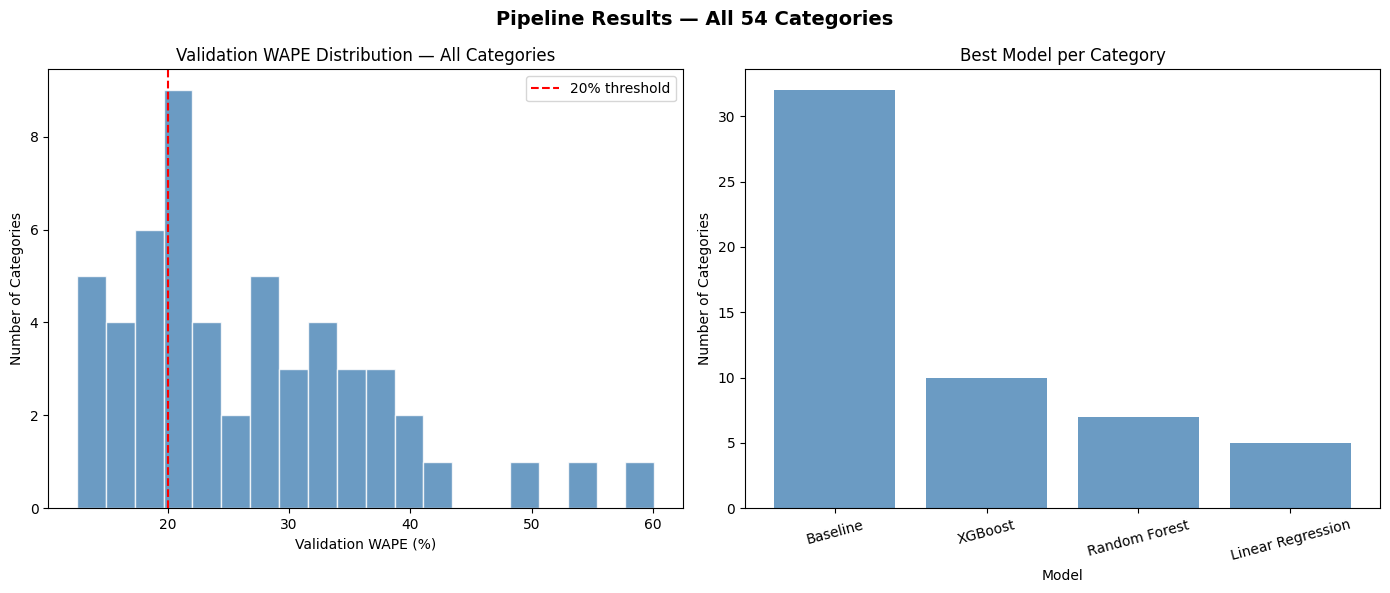


Categories below 20% WAPE: 15/54
Average Val WAPE: 26.7%
Median Val WAPE:  24.0%


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# WAPE distribution
axes[0].hist(summary_df["Val WAPE (%)"], bins=20,
             color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(x=20, color="red", linestyle="--",
                label="20% threshold")
axes[0].set_title("Validation WAPE Distribution — All Categories")
axes[0].set_xlabel("Validation WAPE (%)")
axes[0].set_ylabel("Number of Categories")
axes[0].legend()

# Best model distribution
model_counts = summary_df["Best Model"].value_counts()
axes[1].bar(model_counts.index, model_counts.values,
            color="steelblue", alpha=0.8)
axes[1].set_title("Best Model per Category")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Number of Categories")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Pipeline Results — All 54 Categories",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nCategories below 20% WAPE: "
      f"{(summary_df['Val WAPE (%)'] < 20).sum()}/54")
print(f"Average Val WAPE: {summary_df['Val WAPE (%)'].mean():.1f}%")
print(f"Median Val WAPE:  {summary_df['Val WAPE (%)'].median():.1f}%")